# Data Exploration

## Import packages

In [3]:
## Standard imports
import pandas as pd
import matplotlib.pyplot as plt

## Utilities
import re
from pandas.plotting import scatter_matrix


## Importing the data

I will import only training dataset for data exploration, in order to avoid any bias.

In [23]:
car_data = pd.read_pickle("../data/car_data_train_set.pkl")
car_data.head()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
1619,Mahindra,Scorpio S2,650000,2015,104000,Diesel,Manual,Roorkee,White,First,Individual,2523 cc,75 bhp @ 3200 rpm,200 Nm @ 1400 rpm,RWD,4456.0,1820.0,1930.0,8.0,60.0
1172,Hyundai,Verna Fluidic 1.6 CRDi SX,545000,2014,74000,Diesel,Manual,Mohali,Grey,First,Individual,1582 cc,126 bhp @ 4000 rpm,260 Nm @ 1900 rpm,FWD,4370.0,1700.0,1475.0,5.0,43.0
312,Toyota,Fortuner 3.0 4x2 AT,1525000,2014,72000,Diesel,Automatic,Delhi,White,First,Individual,2982 cc,169 bhp @ 3600 rpm,360 Nm @ 1400 rpm,RWD,4705.0,1840.0,1850.0,7.0,80.0
75,Honda,Jazz VX Petrol,570000,2017,92270,Petrol,Manual,Mumbai,Brown,First,Individual,1199 cc,89 bhp @ 6000 rpm,110 Nm @ 4800 rpm,FWD,3955.0,1694.0,1544.0,5.0,40.0
522,Hyundai,i10 Sportz 1.2,270000,2010,86000,Petrol,Manual,Chennai,Grey,Second,Individual,1197 cc,80@5200,111@4000,FWD,3565.0,1595.0,1550.0,5.0,35.0


Since we intend to treat Engine as a numerical feature, we need to extract the numerical value from the string.

In [5]:
def extractNumber(x):
    if type(x) is str:
        return int((re.search(r"\d+", x).group()))
    else:
        return x

car_data["Engine"] = car_data["Engine"].apply(extractNumber)

## Exploring the data

To begin with let's look at the correlation matrix

In [6]:
corr = car_data.corr(numeric_only = True)
corr["Price"].sort_values()

Kilometer            -0.146707
Seating Capacity     -0.049565
Height                0.067754
Year                  0.319132
Length                0.550663
Width                 0.564872
Fuel Tank Capacity    0.593107
Engine                0.607799
Price                 1.000000
Name: Price, dtype: float64

We get some very strong positive correlations between Price and: 
- Engine
- Fuel Tank Capacity
- Width
- Length
- Year

We also get a negative correlation between Price and:
- Kilometer

Whereas the correlation between Price and Height or Price and Seating Capacity is really minimal

Let's visualize this by plotting the scatter matrix

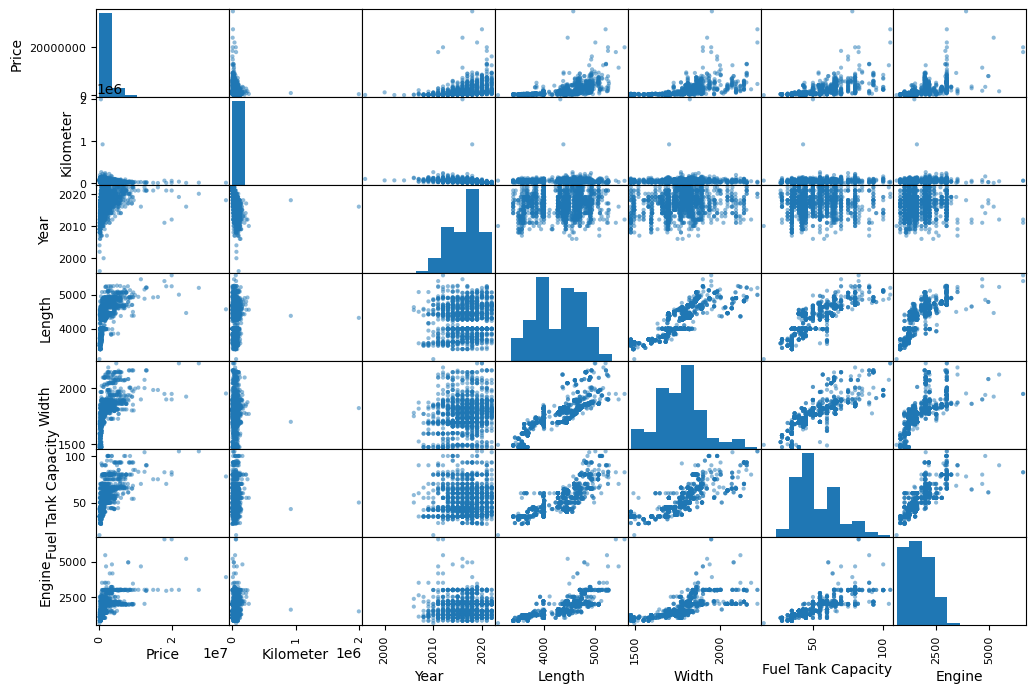

In [7]:
attributes = ["Price", "Kilometer", "Year", "Length", "Width", "Fuel Tank Capacity", "Engine"]

scatter_matrix(car_data[attributes], figsize=(12,8))
plt.show()

The histograms are not very useful, but we can see immediately that various features are closely linearly related. In particular, Length, Width, Engine, and Fuel Tank Capacity are closely linearly correlated. This makes sense, as larger engine and fuel tanks are required for larger cars.

We can also see the linear correlations between Price and all these features that we observed from the correlation matrix.

A worry here is that a number of features (Length, Width, Fuel Tank Capacity, Engine) are very strongly linearly correlated to one another. This kind of **collinearity of features** can be problematic for certain ML algorithm, e.g. Linear Regression. Let's look at the correlation coefficients:

In [8]:
car_data[["Length", "Width", "Fuel Tank Capacity", "Engine"]].corr()

,Length,Width,Fuel Tank Capacity,Engine
Length,1.000000,0.813498,0.817515,0.793887
Width,0.813498,1.000000,0.800261,0.714123
Fuel Tank Capacity,0.817515,0.800261,1.000000,0.802341
Engine,0.793887,0.714123,0.802341,1.000000


We see there is strong collinearity between many of these features, with coefficients greater than 0.8. It may be worth dropping some of these variables when using Linear Regression, or using PCA to reduce the dimensionality of problem, or using Ridge Regression to prevent coefficients of collinear features from blowing up.

The histograms for Price and Kilometers are really unhelpful, so I will plot those individually to try and get a better sense of their distributions.

<Axes: >

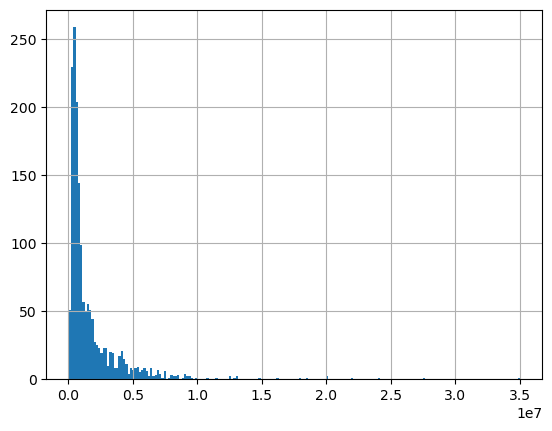

In [9]:
car_data["Price"].hist(bins=200)

We see a distribution heavily skewed to the left. So it may be worthwile to take the logarithm of the target, and predict that. 

<Axes: >

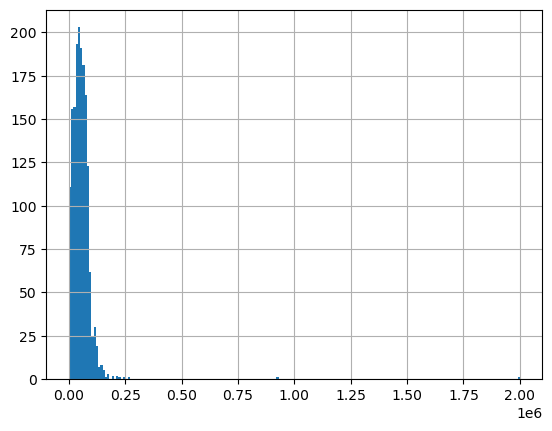

In [10]:
car_data["Kilometer"].hist(bins=200)

Very similar distribution for Kilometer feature

What would happen if we tried to standardize these features?

In [11]:
from sklearn.preprocessing import StandardScaler
import numpy as np
std_scaler = StandardScaler()
car_data_tmp = car_data.copy()
car_data_tmp["Price"] = car_data_tmp["Price"].apply(lambda x: np.log(x))
car_data_tmp["Kilometer"] = car_data_tmp["Kilometer"]

car_price_scaled = std_scaler.fit_transform(car_data_tmp[["Price", "Kilometer"]])

car_price_scaled

array([[-0.43517606,  0.81002959],
       [-0.61364733,  0.32252104],
       [ 0.4286597 ,  0.29002047],
       ...,
       [-0.56821516, -0.29498979],
       [-0.47490537,  0.22501933],
       [ 0.16885381, -0.26248922]], shape=(1647, 2))

(array([  2.,  21., 193., 463., 383., 261., 197., 108.,  12.,   7.]),
 array([-3.0538512 , -2.38820156, -1.72255191, -1.05690226, -0.39125262,
         0.27439703,  0.94004668,  1.60569632,  2.27134597,  2.93699562,
         3.60264527]),
 <BarContainer object of 10 artists>)

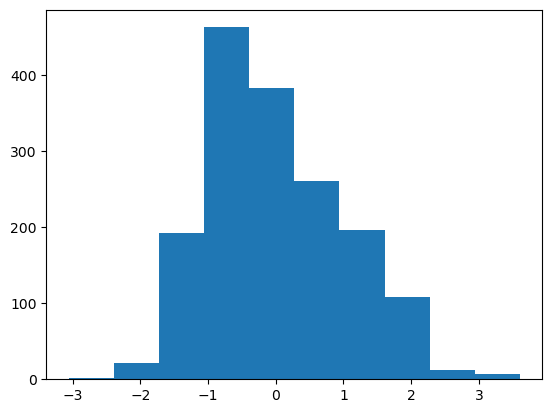

In [12]:
plt.hist(car_price_scaled[:, [0]])

This seems a much nicer distribution to work with.

(array([1.64e+03, 5.00e+00, 0.00e+00, 0.00e+00, 1.00e+00, 0.00e+00,
        0.00e+00, 0.00e+00, 0.00e+00, 1.00e+00]),
 array([-0.88000004,  2.37005695,  5.62011395,  8.87017094, 12.12022794,
        15.37028493, 18.62034193, 21.87039893, 25.12045592, 28.37051292,
        31.62056991]),
 <BarContainer object of 10 artists>)

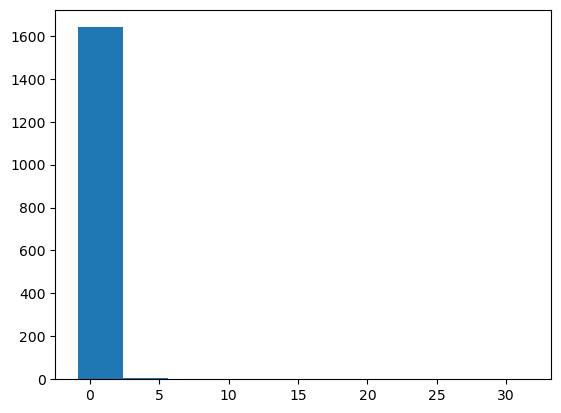

In [13]:
plt.hist(car_price_scaled[:, [1]])

In [14]:
car_data["Kilometer"].describe()

count    1.647000e+03
mean     5.415290e+04
std      6.155607e+04
min      0.000000e+00
25%      2.900000e+04
50%      5.000000e+04
75%      7.200000e+04
max      2.000000e+06
Name: Kilometer, dtype: float64

Kilometer amounts of 1 million or 2 million are likely outliers/mistakes, so might be best to remove them.

(array([372., 509., 466., 212.,  57.,  16.,   6.,   2.,   3.,   2.]),
 array([     0. ,  26123.6,  52247.2,  78370.8, 104494.4, 130618. ,
        156741.6, 182865.2, 208988.8, 235112.4, 261236. ]),
 <BarContainer object of 10 artists>)

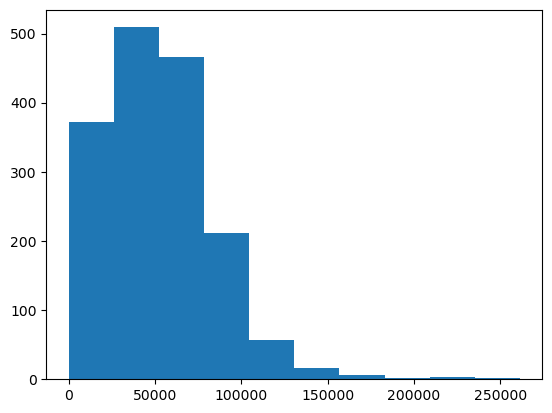

In [15]:
plt.hist(car_data[car_data["Kilometer"] < 750000]["Kilometer"])

In [16]:
car_data[car_data["Engine"] == car_data["Engine"].max()]

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
977,Other Luxury,Ghost 6.5,18000000,2011,60000,Petrol,Automatic,Mumbai,Maroon,Second,Corporate,6592.0,570 bhp @ 5250 rpm,780 Nm @ 1500 rpm,RWD,5399.0,1948.0,1550.0,5.0,82.5
1369,Other Luxury,Ghost Extended Wheelbase,20000000,2012,55000,Petrol,Automatic,Chennai,White,Third or more,Individual,6592.0,570 bhp @ 5250 rpm,780 Nm @ 1500 rpm,RWD,5569.0,1948.0,1550.0,5.0,82.5


(array([ 44., 126., 303., 175., 300.,  33., 274., 116.,  21.,  28.,  32.,
        109.,   6.,   0.,   5.,   0.,   1.,   2.,   0.,   0.,   2.,   3.,
          0.,   1.,   1.,   0.,   0.,   0.,   0.,   2.]),
 array([ 624.        ,  822.93333333, 1021.86666667, 1220.8       ,
        1419.73333333, 1618.66666667, 1817.6       , 2016.53333333,
        2215.46666667, 2414.4       , 2613.33333333, 2812.26666667,
        3011.2       , 3210.13333333, 3409.06666667, 3608.        ,
        3806.93333333, 4005.86666667, 4204.8       , 4403.73333333,
        4602.66666667, 4801.6       , 5000.53333333, 5199.46666667,
        5398.4       , 5597.33333333, 5796.26666667, 5995.2       ,
        6194.13333333, 6393.06666667, 6592.        ]),
 <BarContainer object of 30 artists>)

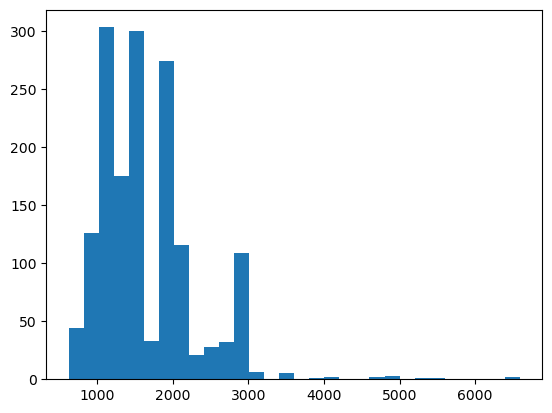

In [17]:
plt.hist(car_data["Engine"], bins=30)

In [18]:
d = std_scaler.fit_transform(car_data_tmp[["Engine"]])

(array([473., 508., 411., 169.,  11.,   3.,   2.,   4.,   1.,   2.]),
 array([-1.64214511, -0.728445  ,  0.18525511,  1.09895522,  2.01265534,
         2.92635545,  3.84005556,  4.75375567,  5.66745578,  6.58115589,
         7.494856  ]),
 <BarContainer object of 10 artists>)

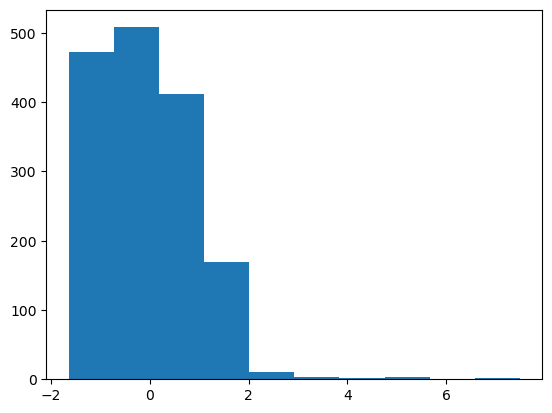

In [19]:
plt.hist(d[:, [0]])

Standard scaler may be appropriate here too.

(array([  1.,   1.,   1.,   3.,  15., 106., 329., 294., 600., 297.]),
 array([1996. , 1998.6, 2001.2, 2003.8, 2006.4, 2009. , 2011.6, 2014.2,
        2016.8, 2019.4, 2022. ]),
 <BarContainer object of 10 artists>)

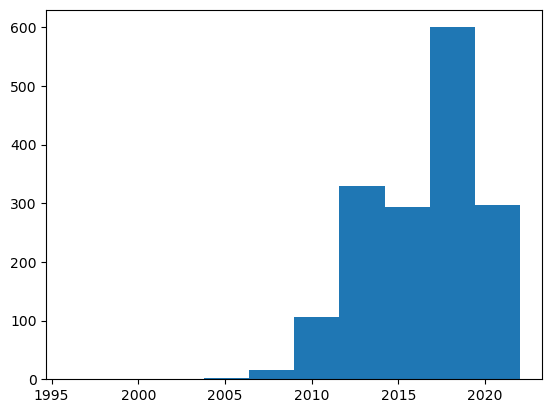

In [20]:
plt.hist(car_data["Year"])

In [21]:
d = std_scaler.fit_transform(car_data_tmp[["Year"]])

(array([  1.,   1.,   1.,   3.,  36.,  85., 329., 294., 600., 297.]),
 array([-6.18778042, -5.40146333, -4.61514624, -3.82882915, -3.04251206,
        -2.25619497, -1.46987788, -0.68356079,  0.1027563 ,  0.88907339,
         1.67539049]),
 <BarContainer object of 10 artists>)

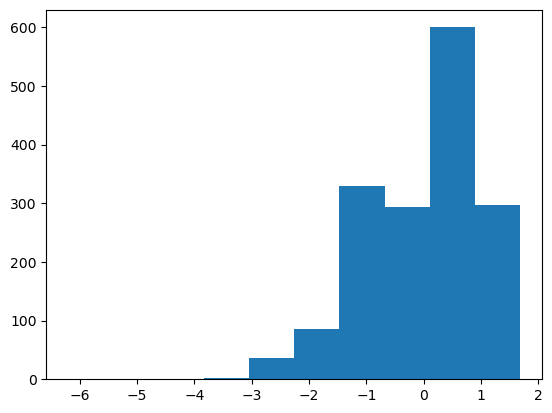

In [22]:
plt.hist(d[:, [0]])

Standard scaler works well here too.